In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Diwali Sales Data.csv to Diwali Sales Data.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Diwali Sales Data.csv", encoding='unicode_escape')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1LEiA8nqXl9ojZg4SL93WkC5p4vaFb4ssd1RBE5VxURI/edit#gid=0


In [ ]:
print(df.isnull().sum())

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64


In [ ]:
#identify non-numeric columns
non_numeric_cols=df.select_dtypes(exclude=['number']).columns

#fill missing values in numeric columns only
for col in df.columns:
  if col not in non_numeric_cols:
    df[col]=df[col].fillna(df[col].mean)

In [ ]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
#clean column names
df.columns=df.columns.str.strip()

In [ ]:
#correct data types
df['User_ID']=df['User_ID'].astype(str)
df['Product_ID']=df['Product_ID'].astype(str)
df['Amount']=pd.to_numeric(df['Amount'],errors='coerce')


In [ ]:
#handle missing values
for col in df.select_dtypes(include=['float64','int64']).columns:
  df[col].fillna(df[col].median(),inplace=True)

/tmp/ipython-input-3715626857.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
  df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipython-input-1229490074.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [ ]:
#handle outliners in amount
Q1=df['Amount'].quantile(0.25)
Q3=df['Amount'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df = df[(df['Amount']>=lower_bound) & (df['Amount'] <= upper_bound)]



In [ ]:
#drop unnecessary columns
if 'Product_Categ Orders' in df.columns:
  df.drop(['Product_Categ Orders'],axis=1,inplace=True)

In [ ]:
#saved cleaned dataset
df.to_csv('Diwali_cleaned.csv',index=False)
print("\data cleaning done! cleaned file saved as 'Diwali_cleaned.csv' ")
print("\n Final dataset shape:", df.shape)
print(df.head())

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1950746066.py:3: SyntaxWarning: invalid escape sequence '\d'
  print("\data cleaning done! cleaned file saved as 'Diwali_cleaned.csv' ")


\data cleaning done! cleaned file saved as 'Diwali_cleaned.csv' 

 Final dataset shape: (11223, 15)
    User_ID Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
7   1002092  Shivangi  P00273442      F       55+   61               0   
14  1003858      Cano  P00293742      M     46-50   46               1   
16  1005447       Amy  P00275642      F     46-50   48               1   
24  1000900    Skaria  P00317842      M       55+   83               0   
25  1005908      Eric  P00282642      F     26-35   33               0   

             State      Zone   Occupation Product_Category  Orders   Amount  \
7      Maharashtra   Western    IT Sector             Auto       1   8109.0   
14  Madhya Pradesh   Central  Hospitality             Auto       3   8109.0   
16  Andhra Pradesh  Southern    IT Sector             Auto       3   8109.0   
24       Karnataka  Southern   Automobile             Auto       3  23513.0   
25  Andhra Pradesh  Southern    IT Sector             Auto  

In [ ]:
import pandas as pd
df = pd.read_csv("Diwali Sales Data.csv", encoding='unicode_escape')

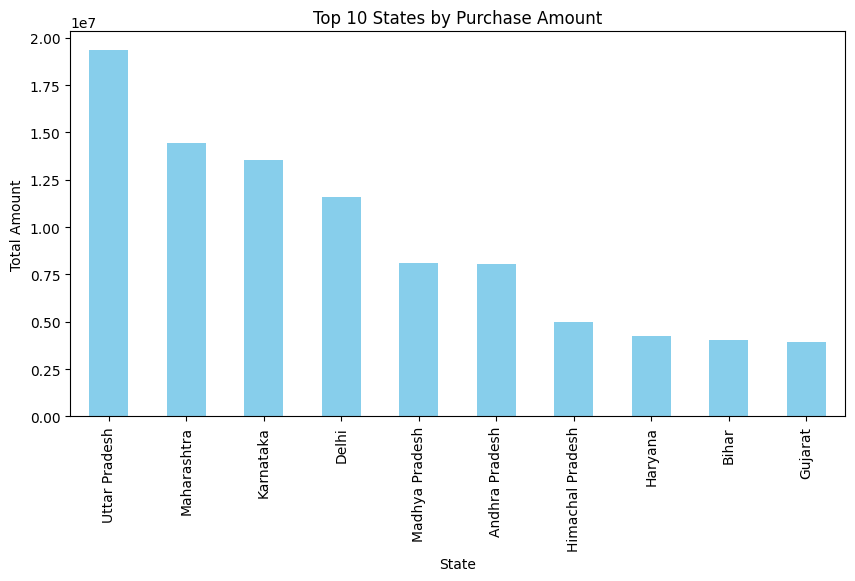

In [ ]:
state_summary = df.groupby("State")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
state_summary.plot(kind="bar", color="skyblue")
plt.title("Top 10 States by Purchase Amount")
plt.ylabel("Total Amount")
plt.show()

/tmp/ipython-input-3121658261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_summary, x="Gender", y="Amount", palette="pastel")


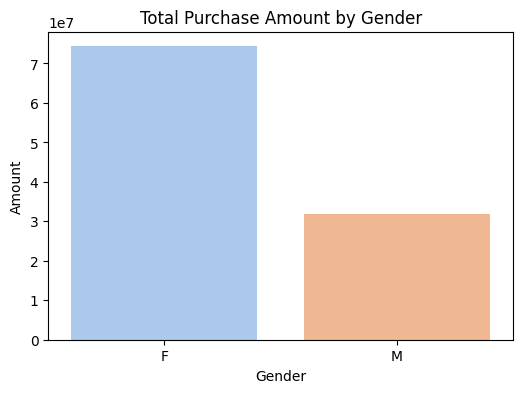

In [ ]:
import seaborn as sns
gender_summary = df.groupby("Gender")["Amount"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=gender_summary, x="Gender", y="Amount", palette="pastel")
plt.title("Total Purchase Amount by Gender")
plt.show()

/tmp/ipython-input-3136182601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occ_summary, x="Occupation", y="Amount", palette="coolwarm")


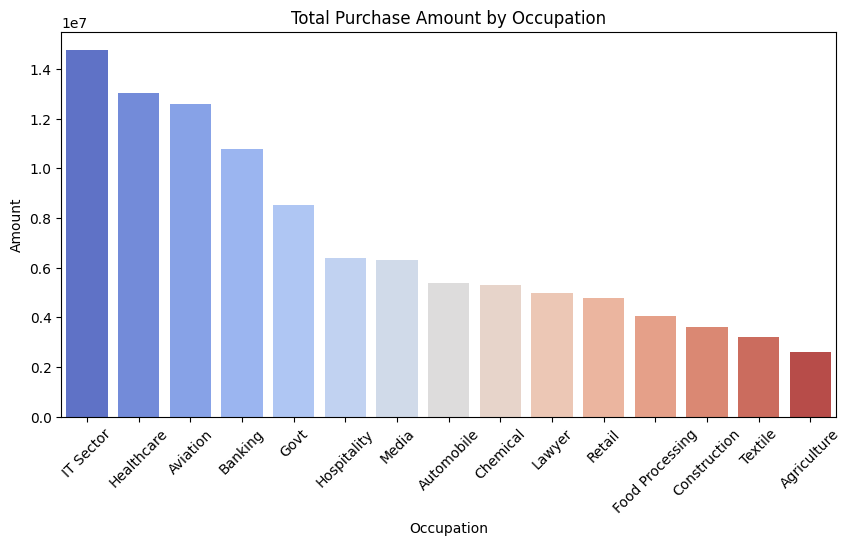

In [ ]:
occ_summary = df.groupby("Occupation")["Amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=occ_summary, x="Occupation", y="Amount", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Total Purchase Amount by Occupation")
plt.show()

/tmp/ipython-input-1226056405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x="Product_Category", y="Amount", palette="viridis")


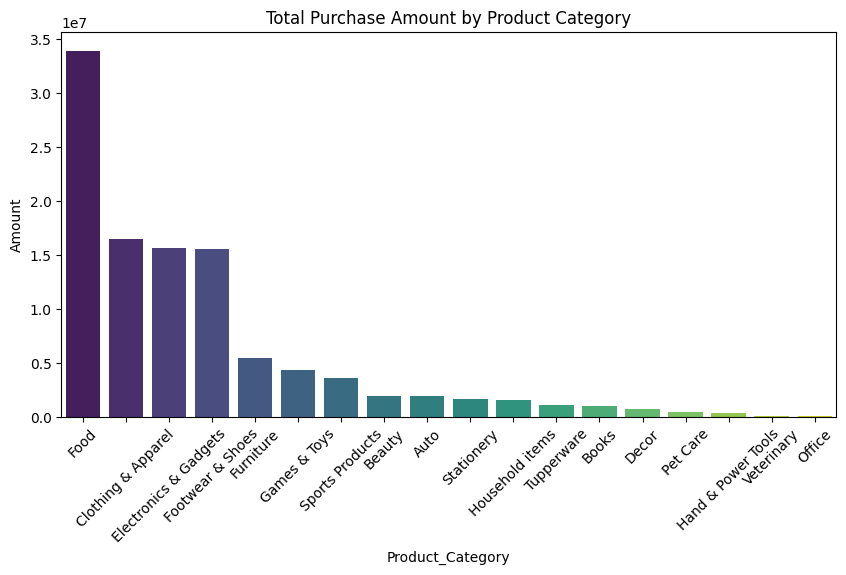

In [ ]:
cat_summary = df.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=cat_summary, x="Product_Category", y="Amount", palette="viridis")
plt.xticks(rotation=45)
plt.title("Total Purchase Amount by Product Category")
plt.show()

/tmp/ipython-input-432794010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x="Age Group", y="Amount", palette="muted")


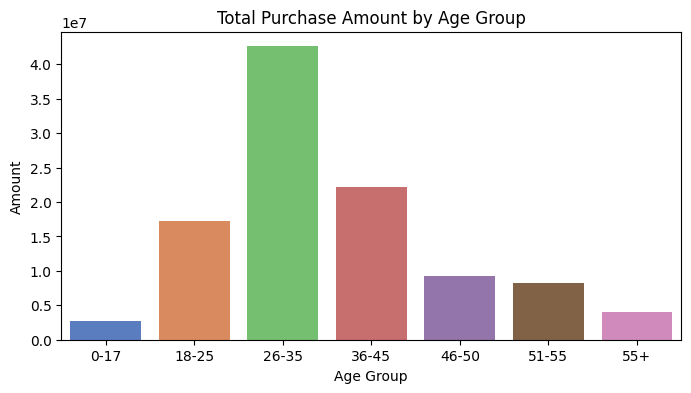

In [ ]:
age_summary = df.groupby("Age Group")["Amount"].sum().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=age_summary, x="Age Group", y="Amount", palette="muted")
plt.title("Total Purchase Amount by Age Group")
plt.show()

/tmp/ipython-input-2202252438.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=marital_summary, x="Marital_Status", y="Amount", palette="Set2")


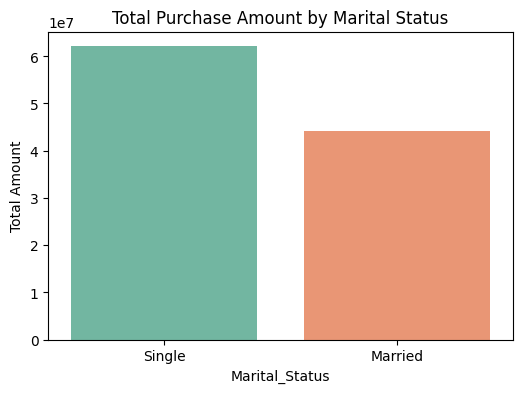

In [ ]:
# Marital Status vs Purchase Amount
marital_summary = df.groupby("Marital_Status")["Amount"].sum().reset_index()

# Replace 0/1 with labels
marital_summary["Marital_Status"] = marital_summary["Marital_Status"].map({0: "Single", 1: "Married"})

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(data=marital_summary, x="Marital_Status", y="Amount", palette="Set2")
plt.title("Total Purchase Amount by Marital Status")
plt.ylabel("Total Amount")
plt.show()

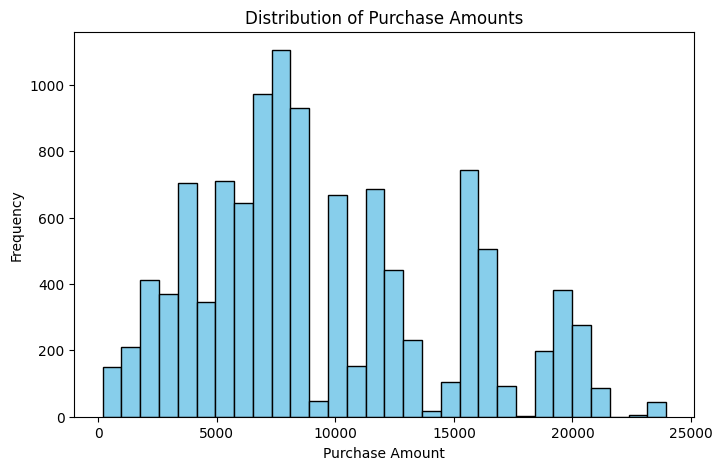

In [ ]:
# Histogram of Purchase Amount
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-804023651.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_summary, x="Zone", y="Amount", palette="Set3")


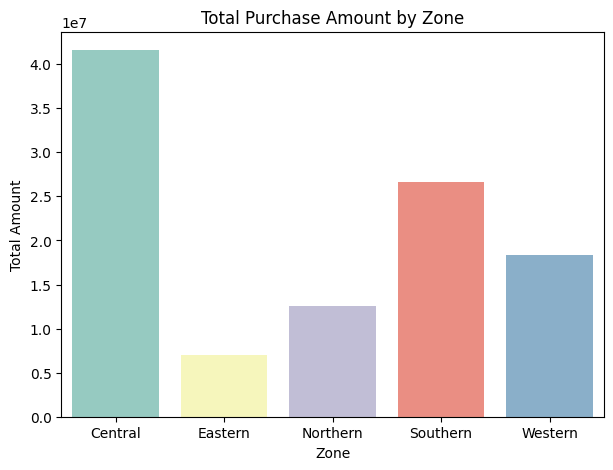

In [ ]:
# Zone vs Purchase Amount
zone_summary = df.groupby("Zone")["Amount"].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=zone_summary, x="Zone", y="Amount", palette="Set3")
plt.title("Total Purchase Amount by Zone")
plt.ylabel("Total Amount")
plt.show()